# RECONOCIMIENTO DE EMOCIONES FACIALES

**BIBLIOTECAS**

In [ ]:
import os
import cv2
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.utils import to_categorical

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation,MaxPooling2D, Dropout, Flatten, Dense, Input
from sklearn.model_selection import train_test_split


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Carga del dataset obtenido de Kaggle**

In [ ]:
# Defino la ruta base del dataset en Drive:
base_dir = "/content/drive/MyDrive/Colab Notebooks/Procesamiento de imagen/base de datos/archive (1)"

In [ ]:
# Mapeo las carpetas a etiquetas en texto con nombres más fácil de comprender.

emotion_folders = {
    "fear":    "Miedo",
    "angry":   "Enojo",
    "sad":     "Triste",
    "neutral": "Neutral",
    "disgust": "Asco",
    "happy":   "Feliz",
    "surprise":"Sorpresa"
}


# Recorremos cada carpeta y armamos listas de rutas y etiquetas
paths = []
labels = []

for folder_name, etiqueta_texto in emotion_folders.items():
    folder_path = os.path.join(base_dir, folder_name)
    if not os.path.isdir(folder_path):
        print(f"Aviso: no existe la carpeta {folder_path}")
        continue

    # Listar todos los archivos JPG/PNG (filtramos por extensión)
    for filename in os.listdir(folder_path):
        lowername = filename.lower()
        if lowername.endswith(".jpg") or lowername.endswith(".jpeg") or lowername.endswith(".png"):
            full_path = os.path.join(folder_path, filename)
            paths.append(full_path)
            labels.append(etiqueta_texto)

In [ ]:
#  Construcción del DataFrame
df = pd.DataFrame({
    "ruta": paths,
    "etiqueta": labels
})

#  Desordeno (shuffle) y reseteo índice
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

**ANÁLISIS EDA**

Visualizamos el total de imágenes del dataset junto con el nombre de las emociones y la cantidad de imágenes correspondiente a cada una.

In [ ]:
#  Mostrar conteo por clase y primeras filas
print("Total de imágenes encontradas:", len(df))
print(df["etiqueta"].value_counts())

df.head(10)

Total de imágenes encontradas: 2938
etiqueta
Enojo       420
Asco        420
Miedo       420
Feliz       420
Neutral     420
Sorpresa    419
Triste      419
Name: count, dtype: int64


,ruta,etiqueta
0,/content/drive/MyDrive/Colab Notebooks/Procesa...,Sorpresa
1,/content/drive/MyDrive/Colab Notebooks/Procesa...,Enojo
2,/content/drive/MyDrive/Colab Notebooks/Procesa...,Asco
3,/content/drive/MyDrive/Colab Notebooks/Procesa...,Miedo
4,/content/drive/MyDrive/Colab Notebooks/Procesa...,Neutral
5,/content/drive/MyDrive/Colab Notebooks/Procesa...,Enojo
6,/content/drive/MyDrive/Colab Notebooks/Procesa...,Feliz
7,/content/drive/MyDrive/Colab Notebooks/Procesa...,Asco
8,/content/drive/MyDrive/Colab Notebooks/Procesa...,Miedo
9,/content/drive/MyDrive/Colab Notebooks/Procesa...,Feliz


Exploración rápida de algunas muestras por clase (esto nos sirve también para comprobar que la ruta y la etiqueta sean correctas)

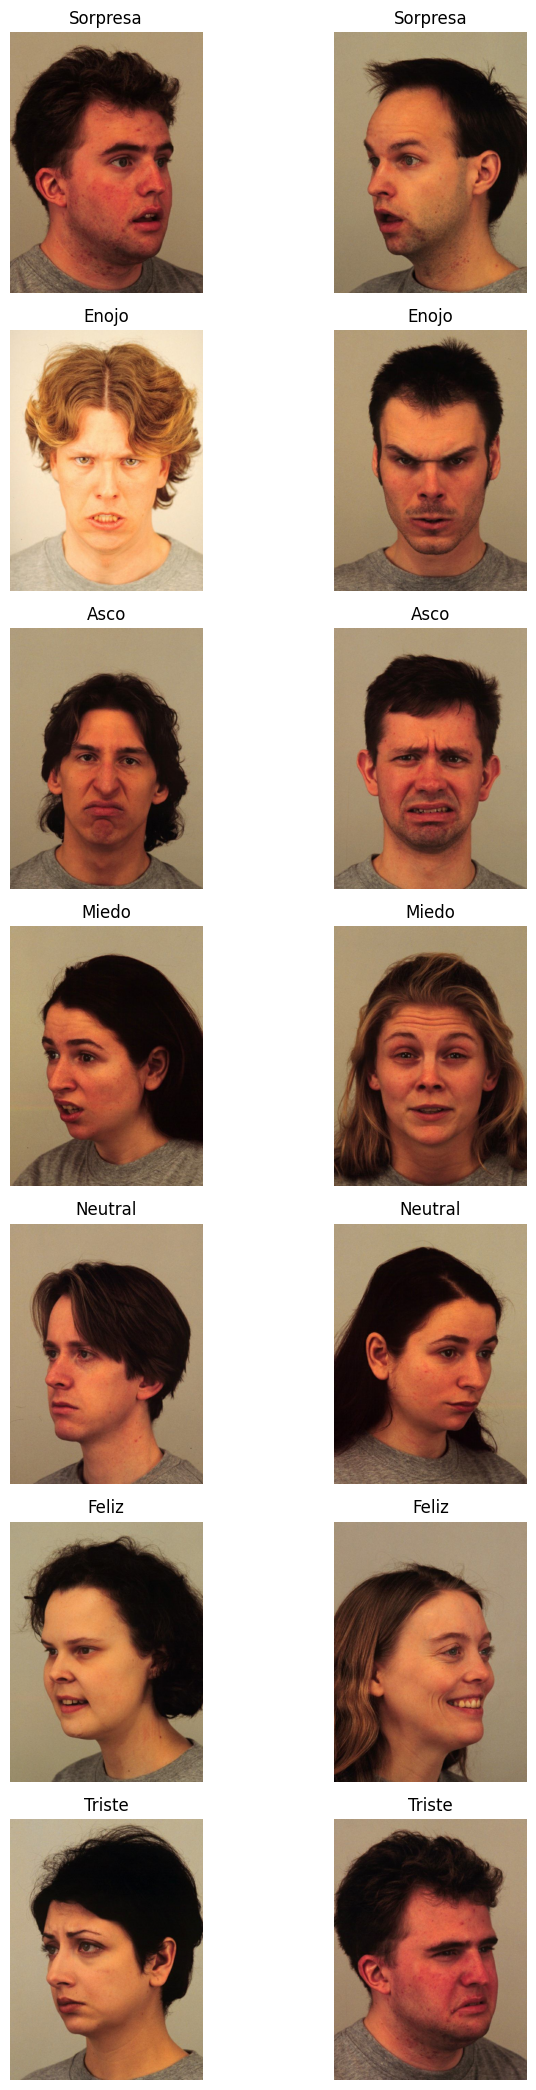

In [ ]:
# Tomamos una muestra de 2 imágenes por cada clase

muestras_por_clase = 2
clases = df["etiqueta"].unique()
filas = len(clases)
cols = muestras_por_clase

plt.figure(figsize=(4*cols, 3*filas))
for i, clase in enumerate(clases):
    sub_df = df[df["etiqueta"] == clase].sample(muestras_por_clase, random_state=42)
    for j, (_, row) in enumerate(sub_df.iterrows()):
        img_path = row["ruta"]

        # Leemos la imagen en BGR (OpenCV) y la convertimos a RGB para  verla con Matplotlib
        img_bgr = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        plt.subplot(filas, cols, i*cols + j + 1)
        plt.imshow(img_rgb)
        plt.title(f"{clase}")
        plt.axis("off")

plt.tight_layout()
plt.show()


Visualizamos la distribución de clases

Conteo de imágenes por emoción:
 etiqueta
Asco        420
Enojo       420
Feliz       420
Miedo       420
Neutral     420
Sorpresa    419
Triste      419
Name: count, dtype: int64


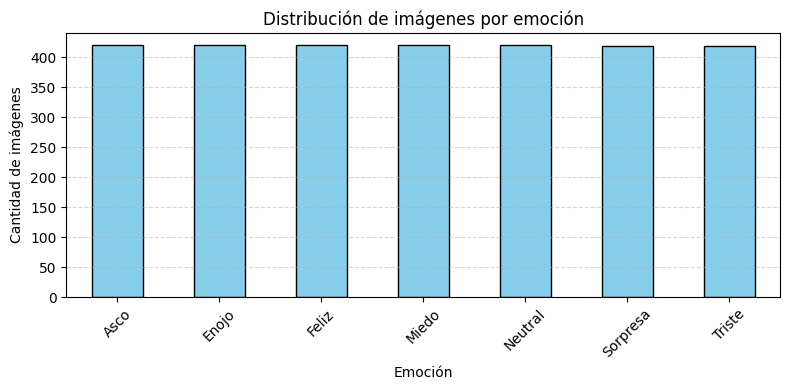

In [ ]:
# Conteo de la cantidad de imágenes por clase
conteo_clases = df["etiqueta"].value_counts().sort_index()               # devuelve cuántas filas (imágenes) hay de cada valor único en df["etiqueta"].

print("Conteo de imágenes por emoción:\n", conteo_clases)

# 1.3 Gráfica de barras
plt.figure(figsize=(8,4))
conteo_clases.plot(kind="bar", color="skyblue", edgecolor="k")
plt.title("Distribución de imágenes por emoción")
plt.xlabel("Emoción")
plt.ylabel("Cantidad de imágenes")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


La distribución de clases nos permite ver cuán balanceado está el dataset. Si una clase tuviera muchas menos imágenes, habría que considerar técnicas de  data augmentation para equilibrar.

A simple vista vemos que el dataset no se consideraría desbalanceado, ya que la falta de imágen para dos clases  (sorpresa y triste) es solo de una.

Visualización de más imágenes por clase



Clases encontradas: ['Asco', 'Enojo', 'Feliz', 'Miedo', 'Neutral', 'Sorpresa', 'Triste']


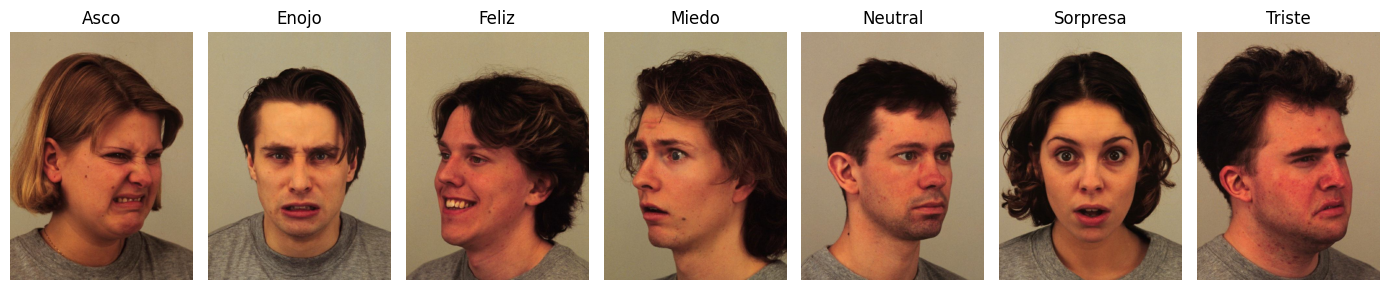

In [ ]:
# Listar las clases en orden alfabético (para consistencia)
clases_unicas = sorted(df["etiqueta"].unique())
print("Clases encontradas:", clases_unicas)

# Para cada clase, tomamos la primera fila que coincida (o podemos tomar una al azar)
rutas_por_clase = []
for clase in clases_unicas:
    # Filtrar el DataFrame por esa clase y tomar la primera ruta
    ruta_ejemplo = df[df["etiqueta"] == clase]["ruta"].iloc[0]           # .sample(n=1) si quisiera que sea aleatorio
    rutas_por_clase.append(ruta_ejemplo)

# Visualizar cada imagen en un subplot
plt.figure(figsize=(14, 4))
for i, (clase, ruta_img) in enumerate(zip(clases_unicas, rutas_por_clase)):
    img_bgr = cv2.imread(ruta_img)                                # OpenCV lee en BGR
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)            # Convertir a RGB para matplotlib

    plt.subplot(1, len(clases_unicas), i+1)
    plt.imshow(img_rgb)
    plt.title(clase)
    plt.axis("off")

plt.tight_layout()
plt.show()


Analizamos los tamaños de las imágenes

Aunque este set de datos aparentemente viene con imágenes uniformes, conviene comprobarlo. Para ello, podemos recorrer por ejemplo una muestra de todo el DataFrame y recolectar los tamaños (alto × ancho). Luego ver cuántas imágenes de cada tamaño existen.

In [ ]:
#  Recorrer todas las rutas y extraer sus dimensiones
#  Para ello, usamos un diccionario para contar cuántas veces aparece cada tamaño (alto, ancho).
from collections import Counter

counter_tamanos = Counter()

for ruta_img in df["ruta"]:
    img = cv2.imread(ruta_img)                                     # Con cv2.imread, leemos la imagen completa en BGR. img.shape[:2] devuelve un tuple (alto, ancho).
    if img is None:                                                # Si img es None, significa que no se pudo leer la imagen.
        # Si alguna imagen no carga, lo notificamos
        print(f"No se pudo leer imagen: {ruta_img}")
        continue
    alto, ancho = img.shape[:2]
    counter_tamanos[(alto, ancho)] += 1                              # Vamos contando con Counter() cuántas veces aparece cada (alto, ancho).

# Mostramos los tamaños únicos y su frecuencia
print("Tamaños únicos de imágenes encontrados (alto × ancho) y cuántas hay de cada uno:")
for (alto, ancho), freq in counter_tamanos.items():
    print(f"  {alto}×{ancho} px ---> {freq} archivos")


Tamaños únicos de imágenes encontrados (alto × ancho) y cuántas hay de cada uno:
  762×562 px ---> 2937 archivos
  970×633 px ---> 1 archivos


Poder conocer si todas las imágenes vienen con la misma resolución y/o tamaño, nos sirve de utilidad para poder así dimensionar la CNN a un solo tamaño.

Si hubieran varios tamaños (p.ej. algunas 350×350 y otras 640×480), tendríamos que decidir uniformizar todas (por ejemplo, a 48×48 o 64×64) antes de entrenar.

En este caso, casi todas las imágenes tienen el tamaño 762×562 px, salvo una que es de 970×633 px. Con lo cual, conviene inspeccionar esa imagen atípica para decidir qué hacer, si borrarla o simplemente redimensionarla igual que el resto.
Vamos a localizarla y mostrarla para ver mejor de qué se trata.

Visualizamos un ejemplo por cada tamaño distinto

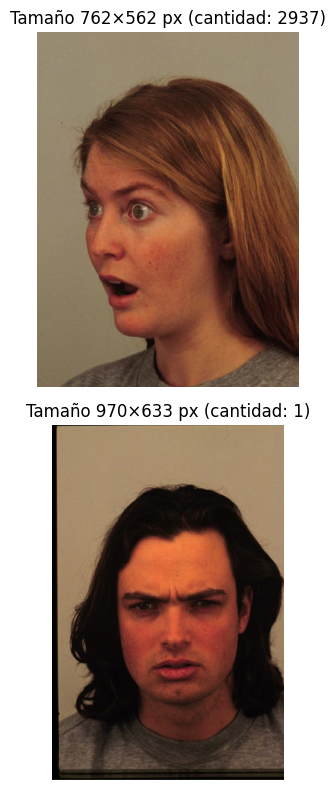

In [ ]:
# Obtener una muestra por cada tamaño distinto

plt.figure(figsize=(12, 4 * len(counter_tamanos)))
for idx, ((alto, ancho), freq) in enumerate(counter_tamanos.items()):

    # Buscamos la primera imagen que tenga esa dimensión
    for ruta_img in df["ruta"]:
        img_temp = cv2.imread(ruta_img)
        if img_temp is None:
            continue
        if img_temp.shape[:2] == (alto, ancho):

            # Convertimos a RGB para mostrar
            img_rgb = cv2.cvtColor(img_temp, cv2.COLOR_BGR2RGB)
            plt.subplot(len(counter_tamanos), 1, idx+1)
            plt.imshow(img_rgb)
            plt.title(f"Tamaño {alto}×{ancho} px (cantidad: {freq})")
            plt.axis("off")
            break

plt.tight_layout()
plt.show()


Podemos observar que la imágen con diferente dimensión presenta bordes negros, y esto estaría ocasionando que cuente con otro tamaño. A la hora de entrenar nuestra red neuronal, estas características no aportarían información extra, con lo cual, lo más sencillo es mantener la imágen y redimensionarla junto con las demás de la misma forma. Así, conservamos todas las imágenes sin eliminar nada.

De esta manera, en el preprocesamiento convertiremos todas a 48 x 48 px, y esos píxeles de borde negro quedarán “aplastados” junto con el resto de la imagen.

**PREPROCESAMIENTO**

Para el preprocesamiento, teniendo en cuenta el EDA, decidimos:
- Mantener los 3 canales de color (RGB). Si bien muchas implementaciones de reconocimiento de emociones usan escala de grises 48x48 (p. ej. Mini-Xception original). También se puede entrenar con 3 canales y 48x48.


- Redimensionar el tamaño de las imágenes a 48x48 px para que todas cuenten con la misma dimensión.

- Normalizar valores a rango [0, 1]: Estandarizo los valores de entrada ya que los modelos funcionan mejor con datos normalizados, por ejemplo entre 0 y 1 o entre -1 y 1. Al estar trabajando con imágenes, para normalizar solo basta con dividir a las imágenes en 255.


- Mapeo: mapeamos cada emoción del df (y) en un valor númerico, para poder trabajar mejor con las clases a la hora de entrenar el modelo (mayor simplicidad).  

- División en train/test estratificada (80/20): Dividimos el df en entrenamiento y testeo de forma estratificada para entrenar el modelo. La estratificación en train_test_split nos garantiza que la proporción de cada clase en el conjunto de entrenamiento y en el de prueba sea muy similar a la del dataset original. Esto es útil cuando tenemos varias clases y queremos asegurarnos de que ninguna quede casi fuera en el test (o en el train). Además, sirve cuando las clases no están perfectamente balanceadas, aunque en nuestro dataset están bastante parejas. Por lo tanto, no es obligatorio aplicarlo para este caso pero sí es muy recomendable, incluso en un dataset relativamente balanceado como 'KDEF'.
Luego dividiremos el set de entrenamiento en un conjunto de Validación para probar diferentes hiperparámetros.


Si bien, no es estrictamente necesario en nuestro dataset aplicar algún filtrado, ya que las imágenes vienen con rostro centrado, fondo uniforme, buena iluminación y sin mucho ruido. Aun así, es buena práctica experimentar con algún filtro en el preprocesamiento para ver si mejora la generalización del modelo. Aplicamos rotaciones y flip.

In [ ]:
# Función de preprocesamiento para UNA imagen

def preprocess_image_color(ruta, tamaño=(48,48)):
    """
    Lee la imagen desde 'ruta' en color (BGR), la convierte a RGB, la redimensiona a 'tamaño',
    normaliza los valores de píxeles a [0,1] y devuelve un array float32 con shape (48,48,3).

    """

    # 1) Leemos la imagen en color (OpenCV devuelve BGR)
    img_bgr = cv2.imread(ruta, cv2.IMREAD_COLOR)
    if img_bgr is None:
        raise ValueError(f"No se pudo leer la imagen: {ruta}")

    # 2) Convertir de BGR a RGB
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)                    # Y debemos convertirla a RGB (porque Keras/TensorFlow normalmente trabajan con imágenes en formato RGB).


    # 3) Redimensionamos a (48,48)
    img_resized = cv2.resize(img_rgb, tamaño, interpolation=cv2.INTER_AREA)       # la redimensiono a (48, 48, 3)


    # 4) Normalizo a [0,1]
    img_norm = img_resized.astype("float32") / 255.0


    # 5) Devolvemos un array con shape (48,48,3)
    return img_norm




# Vamos a “revolver” (shuffle) las filas para que luego X e y se creen en orden aleatorio
df = df.sample(frac=1, random_state=42).reset_index(drop=True)



# 6) Crear listas vacías para almacenar cada imagen procesada y su etiqueta numérica
X = []
y = []


# 7) Mapear cada emoción (texto) a un índice numérico
#    Por ejemplo: {'Asco':0, 'Enojo':1, 'Feliz':2, 'Miedo':3, 'Neutral':4, 'Sorpresa':5, 'Triste':6}
clases_ordenadas = sorted(df["etiqueta"].unique())
label_to_int = {clase: idx for idx, clase in enumerate(clases_ordenadas)}
print("Mapeo de clases a índices:", label_to_int)



# 8) Iterar sobre cada fila de df para preprocesar en color
for idx, row in df.iterrows():
    ruta_img = row["ruta"]
    etiqueta_texto = row["etiqueta"]
    etiqueta_num = label_to_int[etiqueta_texto]
    try:
        # Redimensiona a (48×48) en 3 canales y normaliza
        img_pp = preprocess_image_color(ruta_img, tamaño=(48,48))
        X.append(img_pp)
        y.append(etiqueta_num)
    except Exception as e:
        print(f"Error procesando {ruta_img}: {e}")



# 9) Convertir las listas a arreglos NumPy
X = np.array(X)      # shape: (n_imágenes, 48, 48, 3)
y = np.array(y)      # shape: (n_imágenes,)
print("X.shape =", X.shape)
print("y.shape =", y.shape)





# 11) División estratificada Train/Test (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)        # (X, y_ohe, test_size=0.20, stratify=y, random_state=42) con One-hot

print("X_train.shape =", X_train.shape, "y_train.shape =", y_train.shape)
print("X_test.shape  =", X_test.shape,  "y_test.shape  =", y_test.shape)




Mapeo de clases a índices: {'Asco': 0, 'Enojo': 1, 'Feliz': 2, 'Miedo': 3, 'Neutral': 4, 'Sorpresa': 5, 'Triste': 6}
X.shape = (2938, 48, 48, 3)
y.shape = (2938,)
X_train.shape = (2350, 48, 48, 3) y_train.shape = (2350,)
X_test.shape  = (588, 48, 48, 3) y_test.shape  = (588,)


In [ ]:
# X normalizada  (para corroborar que lo esté)
X

array([[[[0.7019608 , 0.6313726 , 0.48235294],
         [0.7058824 , 0.63529414, 0.48235294],
         [0.7019608 , 0.6313726 , 0.49019608],
         ...,
         [0.69803923, 0.6392157 , 0.4862745 ],
         [0.69803923, 0.6392157 , 0.4862745 ],
         [0.69411767, 0.63529414, 0.48235294]],

        [[0.7058824 , 0.63529414, 0.4862745 ],
         [0.7058824 , 0.63529414, 0.4862745 ],
         [0.7019608 , 0.6313726 , 0.48235294],
         ...,
         [0.69803923, 0.6392157 , 0.47843137],
         [0.69803923, 0.6392157 , 0.4862745 ],
         [0.69803923, 0.6392157 , 0.48235294]],

        [[0.70980394, 0.6392157 , 0.48235294],
         [0.70980394, 0.63529414, 0.47843137],
         [0.7058824 , 0.6313726 , 0.4745098 ],
         ...,
         [0.69803923, 0.6392157 , 0.47843137],
         [0.69803923, 0.6392157 , 0.47843137],
         [0.69803923, 0.6392157 , 0.47843137]],

        ...,

        [[0.57254905, 0.49411765, 0.3647059 ],
         [0.5686275 , 0.49411765, 0.3647059 ]

In [ ]:
# ----------------------------------------------------------
# 1) Definir la función de aumento (DATA AUGMENTATION) :
# ----------------------------------------------------------
def augment_dataset_super_simple(X, y):
    """
    Por cada imagen en X:
      1) Guarda la original.
      2) Gira +10°.
      3) Gira -10°.
      4) Flip horizontal.

    Retorna X_aug y y_aug con 3 imágenes nuevas por cada original (total 4).
    """
    X_list = []
    y_list = []
    N, H, W, C = X.shape

    angle_1 = 10
    angle_2 = -10
    center = (W // 2, H // 2)

    for i in range(N):
        img = X[i]       # float32 en [0,1]
        label = y[i]

        # 1) Imagen original
        X_list.append(img.copy())
        y_list.append(label)

        # 2) Rotar +10°
        M1 = cv2.getRotationMatrix2D(center, angle_1, 1.0)
        rot1 = cv2.warpAffine(
            (img * 255).astype(np.uint8),
            M1,
            (W, H),
            flags=cv2.INTER_LINEAR,
            borderMode=cv2.BORDER_REFLECT
        )
        rot1 = rot1.astype(np.float32) / 255.0
        X_list.append(rot1)
        y_list.append(label)

        # 3) Rotar -10°
        M2 = cv2.getRotationMatrix2D(center, angle_2, 1.0)
        rot2 = cv2.warpAffine(
            (img * 255).astype(np.uint8),
            M2,
            (W, H),
            flags=cv2.INTER_LINEAR,
            borderMode=cv2.BORDER_REFLECT
        )
        rot2 = rot2.astype(np.float32) / 255.0
        X_list.append(rot2)
        y_list.append(label)

        # 4) Flip horizontal de la imagen original
        #    cv2.flip(img, 1) voltea horizontalmente
        flip_h = cv2.flip((img * 255).astype(np.uint8), 1)
        flip_h = flip_h.astype(np.float32) / 255.0
        X_list.append(flip_h)
        y_list.append(label)

    X_aug = np.stack(X_list, axis=0)
    y_aug = np.array(y_list, dtype=y.dtype)
    return X_aug, y_aug

# ----------------------------------------------------------
# 2) División original Train/Test (80%–20%):
# ----------------------------------------------------------

print("Train/Test original:")
print("  X_train:", X_train.shape, "  y_train:", y_train.shape)
print("  X_test: ", X_test.shape,  "  y_test: ", y_test.shape)

# ----------------------------------------------------------
# 3) Aumentar SOLO el conjunto de entrenamiento:
# ----------------------------------------------------------

# Utilizamos la función augment_dataset_super_simple para triplicar (1 original + 2 rotaciones)
X_train_aug, y_train_aug = augment_dataset_super_simple(X_train, y_train)

print("\nDespués de aumentar X_train:")
print("  X_train_aug:", X_train_aug.shape, "  y_train_aug:", y_train_aug.shape)
# Si X_train originalmente era (N, H, W, C), ahora X_train_aug es (3·N, H, W, C)

Train/Test original:
  X_train: (2350, 48, 48, 3)   y_train: (2350,)
  X_test:  (588, 48, 48, 3)   y_test:  (588,)

Después de aumentar X_train:
  X_train_aug: (9400, 48, 48, 3)   y_train_aug: (9400,)


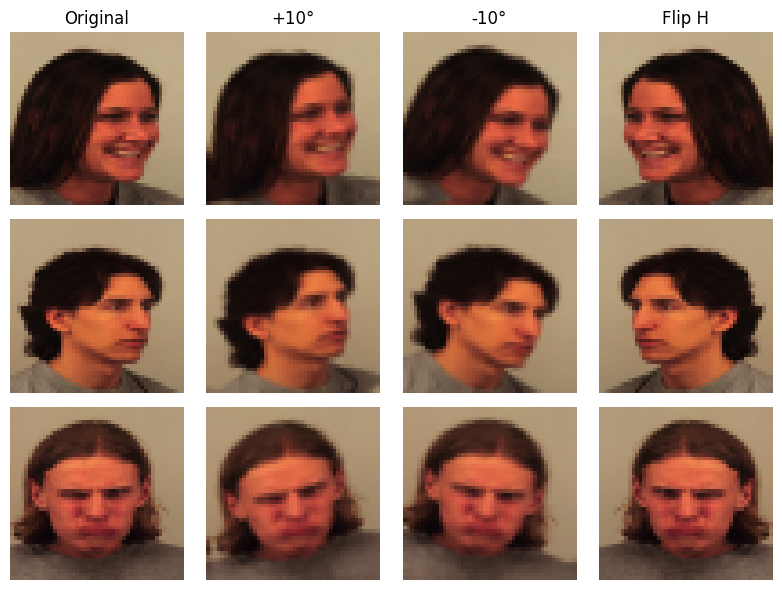

In [ ]:
# ----------------------------------------------------------
# 4) Visualizamos algunos ejemplos originales vs. rotados y flip (con data augmentation):
# ----------------------------------------------------------

# Mostramos, por ejemplo, las primeras 3 imágenes de X_train:
num_display = 3

# Ahora `augment_dataset_super_simple` apila en orden:
#   [original_0, rot+10_0, rot-10_0, flip_0,
#    original_1, rot+10_1, rot-10_1, flip_1, …]
# Es decir, para cada i:
#   índice 4*i     → original,
#   índice 4*i + 1 → rotación +10°,
#   índice 4*i + 2 → rotación -10°,
#   índice 4*i + 3 → flip horizontal.

fig, axes = plt.subplots(num_display, 4, figsize=(8, 2 * num_display))

for i in range(num_display):
    # Imagen original
    orig = X_train[i]            # la i-ésima del conjunto original

    # Índices en el dataset aumentado
    idx_orig = 4 * i
    idx_rotp = 4 * i + 1         # rot +10°
    idx_rotm = 4 * i + 2         # rot -10°
    idx_flip = 4 * i + 3         # flip horizontal

    rotp = X_train_aug[idx_rotp]
    rotm = X_train_aug[idx_rotm]
    fliph = X_train_aug[idx_flip]

    # Mostrar en la fila i:
    for j, img in enumerate([orig, rotp, rotm, fliph]):
        ax = axes[i, j]
        if img.shape[2] == 1:    # imagen en escala de grises
            ax.imshow(img.squeeze(), cmap='gray')
        else:
            ax.imshow(img)       # imagen a color
        ax.axis('off')

        if i == 0:
            # Sólo la primera fila lleva título en cada columna
            if j == 0:    ax.set_title("Original")
            if j == 1:    ax.set_title("+10°")
            if j == 2:    ax.set_title("-10°")
            if j == 3:    ax.set_title("Flip H")

plt.tight_layout()
plt.show()


Preparacionde datos para vgg

In [ ]:
# Preparo las x para VGG-16

# reescalo a [0,255]
X_train_vgg = X_train_aug * 255.0
X_test_vgg  = X_test  * 255.0

In [ ]:
print(X_test_vgg)

[[[[181. 161. 134.]
   [181. 161. 134.]
   [181. 161. 133.]
   ...
   [178. 158. 132.]
   [177. 157. 132.]
   [176. 157. 131.]]

  [[180. 161. 131.]
   [181. 161. 133.]
   [181. 162. 134.]
   ...
   [177. 159. 131.]
   [175. 158. 131.]
   [174. 157. 128.]]

  [[181. 161. 133.]
   [181. 162. 133.]
   [182. 163. 134.]
   ...
   [177. 160. 131.]
   [177. 160. 131.]
   [176. 159. 130.]]

  ...

  [[ 49.  33.  29.]
   [ 41.  28.  25.]
   [ 17.  10.   8.]
   ...
   [ 98.  78.  65.]
   [101.  82.  70.]
   [102.  82.  70.]]

  [[ 98.  77.  67.]
   [ 73.  55.  47.]
   [ 48.  34.  29.]
   ...
   [104.  84.  71.]
   [ 99.  81.  69.]
   [ 99.  80.  68.]]

  [[103.  83.  71.]
   [ 73.  55.  48.]
   [ 78.  60.  51.]
   ...
   [ 97.  78.  68.]
   [ 99.  80.  67.]
   [ 92.  73.  64.]]]


 [[[170. 149. 121.]
   [171. 149. 122.]
   [170. 149. 120.]
   ...
   [170. 149. 121.]
   [171. 149. 123.]
   [171. 150. 124.]]

  [[171. 150. 119.]
   [172. 150. 119.]
   [173. 150. 119.]
   ...
   [174. 150. 122.]
 

In [ ]:
print(X_train_vgg)

[[[[185. 169. 135.]
   [186. 169. 134.]
   [187. 169. 133.]
   ...
   [190. 169. 139.]
   [191. 171. 140.]
   [191. 171. 140.]]

  [[187. 169. 133.]
   [187. 168. 134.]
   [186. 168. 134.]
   ...
   [190. 170. 139.]
   [190. 171. 139.]
   [191. 171. 139.]]

  [[188. 168. 134.]
   [188. 169. 131.]
   [186. 168. 134.]
   ...
   [191. 170. 139.]
   [191. 171. 139.]
   [190. 171. 140.]]

  ...

  [[133. 117.  95.]
   [140. 122.  96.]
   [123. 104.  84.]
   ...
   [122. 105.  82.]
   [148. 128. 100.]
   [161. 141. 111.]]

  [[125. 109.  88.]
   [128. 112.  91.]
   [132. 114.  90.]
   ...
   [ 98.  82.  68.]
   [105.  87.  71.]
   [116. 100.  81.]]

  [[126. 108.  87.]
   [130. 113.  91.]
   [131. 115.  91.]
   ...
   [ 99.  83.  69.]
   [ 97.  80.  68.]
   [106.  89.  73.]]]


 [[[187. 167. 132.]
   [187. 167. 133.]
   [186. 167. 133.]
   ...
   [192. 172. 139.]
   [191. 172. 139.]
   [192. 172. 139.]]

  [[187. 167. 132.]
   [186. 166. 131.]
   [186. 167. 132.]
   ...
   [191. 172. 140.]
 

In [ ]:
# Preparo las x para VGG-16
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
# Lo hice antes
#X_train_vgg = X_train * 255.0
#X_test_vgg  = X_test  * 255.0

# Y aplico el preprocesado específico de VGG-16 (BGR centering):
X_train_vgg = preprocess_input(X_train_vgg)
X_test_vgg  = preprocess_input(X_test_vgg)

Dividisión del dataset aumentado en validación para probar/ajustar diferentes hiperparámetros.

In [ ]:
# ----------------------------------------------------------
# 4) División Train/Validation interna (80%–20%) sobre el conjunto AUMENTADO:
# ----------------------------------------------------------

X_val_train, X_val_test, y_val_train, y_val_test = train_test_split(
    X_train_vgg,            # datos AUMENTADOS de entrenamiento
    y_train_aug,            # etiquetas correspondientes
    test_size=0.20,         # 20% de X_train_aug irá a validación
    stratify=y_train_aug,   # estratificamos según la etiqueta aumentada
    random_state=42
)

print("\nTrain/Validation sobre conjunto aumentado:")
print("  X_val_train:", X_val_train.shape, "  y_val_train:", y_val_train.shape)
print("  X_val_test: ", X_val_test.shape,  "  y_val_test: ",  y_val_test.shape)

# ----------------------------------------------------------
# 5) Ahora tienes tres particiones:
#    • X_val_train, y_val_train  → 80% (80% de X_train_aug)  := uso para ENTRENAR el modelo
#    • X_val_test,  y_val_test   → 20% (20% de X_train_aug)  := uso para validar hiperparámetros
#    • X_test,     y_test        → 20% del total original   := uso para prueba final, SIN AUMENTAR
# ----------------------------------------------------------





Train/Validation sobre conjunto aumentado:
  X_val_train: (7520, 48, 48, 3)   y_val_train: (7520,)
  X_val_test:  (1880, 48, 48, 3)   y_val_test:  (1880,)


Esto significa que 7520 muestras (del conjunto aumentado) serán usadas para validación interna y 1880 muestras (del conjunto aumentado) para evaluación de hiperparametros.



---



**MODELO - CNN**

ARQUITECTURA DE LA RED

Al emplear el modelo pre entrenado VGG-16, debemos reescalar de vuelta los X_train y X_test, antes de pasarlas al modelo, ya que los normalizamos en [0,1]).

MODELO  

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

In [ ]:
# MODELO VGG 2

#  Carga base VGG-16 y fine-tuning parcial
base = VGG16(weights='imagenet',    include_top=False,   input_shape=(48,48,3))

# Congelamos todos los bloques excepto los últimos dos
for layer in base.layers[:-8]:
    layer.trainable = False
for layer in base.layers[-8:]:
    layer.trainable = True

#  Cabeza 'ajustada'
x = base.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)    # capa más ligera
x = Dropout(0.3)(x)
# Opcional: segunda capa densa para ver si mejora
# x = Dense(128, activation='relu')(x)
# x = Dropout(0.2)(x)
outputs = Dense(7, activation='softmax')(x)

model_vgg_2 = Model(inputs=base.input, outputs=outputs)


# Compilación con LR muy bajo para fine-tuning
opt2 = Adam(learning_rate=1e-5)
model_vgg_2.compile(  optimizer=opt2,   loss='sparse_categorical_crossentropy',   metrics=['accuracy'])

model_vgg_2.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 48, 48, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,781,255 (56.39 MB)

 Trainable params: 13,045,767 (49.77 MB)

 Non-trainable params: 1,735,488 (6.62 MB)

In [ ]:
# Callbacks
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

earlystop = EarlyStopping(  monitor='val_accuracy',   patience=8,   restore_best_weights=True,  verbose=1)

reduce_lr = ReduceLROnPlateau(  monitor='val_loss',  factor=0.5,  patience=10,  min_lr=1e-6,  verbose=1)

callbacks = [earlystop, reduce_lr]

In [ ]:
# Entrenamiento con callbacks

#history_vgg_2 = model_vgg_2.fit(X_val_train, y_val_train, validation_data=(X_val_test,y_val_test), batch_size=32,  epochs=25,  callbacks=callbacks)



---



Búsqueda de mejores hiperparámetros

Dado que 'model_vgg_2' ya tiene una estructura definida y un buen rendimiento base, podemos enfocarnos en optimizar sus hiperparámetros clave.

A continuación se implementa un Grid Search "manual" para este modelo, similar a lo que venimos haciendo en el experimento anterior, pero adaptado a los parámetros específicos de model_vgg_2:

In [ ]:
from tensorflow.keras.initializers import GlorotUniform # Solo si quieres variar el inicializador, si no, omítelo


print("Iniciando Grid Search para VGG-16 (model_vgg_2)...")

# Definimos las opciones de los hiperparámetros a optimizar


# Tasa de aprendizaje para el optimizador Adam (actual: 1e-5)
learning_rates = [1e-5, 5e-6, 2e-5]

# Tasa de Dropout en la capa densa (actual: 0.3)
dropout_rates = [0.2, 0.3, 0.4]

# Número de neuronas en la capa Dense de la cabeza (actual: 128)
dense_neurons_options = [64, 128, 256]

# (Opcional) Puedes añadir más:
# Activaciones: ['relu', 'tanh'] (current: relu)
# Paciencia de EarlyStopping: [7, 8, 9] (current: 8)
# Factor de ReduceLROnPlateau: [0.2, 0.5, 0.7] (current: 0.5)

best_accuracy = 0.0
best_params = {}
best_model_tuned = None

# --- Bucle para probar las distintas combinaciones de hiperparámetros ---
for lr in learning_rates:
    for drop_rate in dropout_rates:
        for neurons in dense_neurons_options:
            print(f"\nProbando combinación: LR={lr}, Dropout={drop_rate}, Neuronas={neurons}")

            # Reconstruir el modelo en cada iteración para asegurar pesos limpios
            # y que las capas congeladas se mantengan congeladas.
            base = VGG16(weights='imagenet', include_top=False, input_shape=(48, 48, 3))

            # Congelamos todos los bloques excepto los últimos dos (como en model_vgg_2)
            # Asegúrate que 'base.layers[:-X]' corresponde a los bloques que quieres descongelar.
            # ':-8' suele descongelar 2 bloques convolucionales y sus respectivas capas de activación/pooling,
            # pero depende del detalle de la implementación de VGG16 en Keras (puede variar si hay BatchNormalization o no, etc.)
            # Para VGG16, [-8:] son las últimas 8 capas que suelen incluir el último bloque convolucional y sus subsiguientes.
            # Puedes ajustar esto si "los últimos 1-2 bloques" es un número diferente de capas.
            for layer in base.layers[:-8]: # Congela hasta el penúltimo bloque convolucional
                layer.trainable = False
            for layer in base.layers[-8:]: # Descongela el último bloque convolucional y posiblemente el anterior
                layer.trainable = True

            # Re-construir la cabeza 'ajustada' con los hiperparámetros actuales
            x = base.output
            x = GlobalAveragePooling2D()(x)
            x = Dense(neurons, activation='relu')(x) # Usamos el número de neuronas del bucle
            x = Dropout(drop_rate)(x)                # Usamos la tasa de dropout del bucle
            outputs = Dense(7, activation='softmax')(x)

            model_actual = Model(inputs=base.input, outputs=outputs)

            # Compilación con el LR actual
            opt_current = Adam(learning_rate=lr)
            model_actual.compile(
                optimizer=opt_current,
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy']
            )

            # Callbacks (pueden ser fijos o también variarse en el grid search si es necesario)
            # Se recomienda usar verbose=0 para los callbacks durante el grid search
            earlystop_current = EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=0)
            reduce_lr_current = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=0)
            callbacks_current = [earlystop_current, reduce_lr_current]

            # Entrenar el modelo
            # Se recomienda verbose=0 aquí también para evitar una salida excesiva
            history_actual = model_actual.fit(
                X_val_train, y_val_train,
                validation_data=(X_val_test, y_val_test),
                batch_size=32,
                epochs=30, # Mantén un número fijo de épocas para comparar justamente
                callbacks=callbacks_current,
                verbose=0 # Suprime el output del entrenamiento
            )

            # Evaluar y guardar el mejor modelo/parámetros
            # EarlyStopping restaura los mejores pesos, así que tomamos el accuracy final del modelo evaluado
            val_loss, val_accuracy = model_actual.evaluate(X_val_test, y_val_test, verbose=0)

            print(f" -> Val Accuracy obtenida: {val_accuracy:.4f}")

            if val_accuracy > best_accuracy:
                best_accuracy = val_accuracy
                best_params = {
                    'learning_rate': lr,
                    'dropout_rate': drop_rate,
                    'dense_neurons': neurons
                }
                # Opcional: guardar el mejor modelo encontrado
                # best_model_tuned = model_current # Guarda el modelo completo o solo sus pesos


print("\n--- Grid Search Finalizado ---")
print("Mejores hiperparámetros encontrados:")
print(best_params)
print(f"Mejor Accuracy en validación: {best_accuracy:.4f}")

# Si guardaste el mejor modelo, puedes cargarlo o usar 'best_model_tuned' aquí
# para un entrenamiento final en todo tu conjunto de datos de entrenamiento real (X, y)
# y una evaluación final en el conjunto de prueba (X_test, y_test).

Iniciando Grid Search para VGG-16 (model_vgg_2)...

Probando combinación: LR=1e-05, Dropout=0.2, Neuronas=64
 -> Val Accuracy obtenida: 0.9149

Probando combinación: LR=1e-05, Dropout=0.2, Neuronas=128
 -> Val Accuracy obtenida: 0.9191

Probando combinación: LR=1e-05, Dropout=0.2, Neuronas=256
 -> Val Accuracy obtenida: 0.9229

Probando combinación: LR=1e-05, Dropout=0.3, Neuronas=64
 -> Val Accuracy obtenida: 0.9170

Probando combinación: LR=1e-05, Dropout=0.3, Neuronas=128
 -> Val Accuracy obtenida: 0.9128

Probando combinación: LR=1e-05, Dropout=0.3, Neuronas=256
 -> Val Accuracy obtenida: 0.9154

Probando combinación: LR=1e-05, Dropout=0.4, Neuronas=64
 -> Val Accuracy obtenida: 0.9154

Probando combinación: LR=1e-05, Dropout=0.4, Neuronas=128
 -> Val Accuracy obtenida: 0.9154

Probando combinación: LR=1e-05, Dropout=0.4, Neuronas=256
 -> Val Accuracy obtenida: 0.8995

Probando combinación: LR=5e-06, Dropout=0.2, Neuronas=64
 -> Val Accuracy obtenida: 0.8234

Probando combinación: 



---



In [ ]:
#  MODELO CON MEJORES HIPERPARÁETROS


#  Carga base VGG-16 y fine-tuning parcial
base = VGG16(weights='imagenet',    include_top=False,   input_shape=(48,48,3))

# Congelamos todos los bloques excepto los últimos dos
for layer in base.layers[:-8]:
    layer.trainable = False
for layer in base.layers[-8:]:
    layer.trainable = True

#  Cabeza 'ajustada'
x = base.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)    # capa más ligera
x = Dropout(0.2)(x)

outputs = Dense(7, activation='softmax')(x)

model_vgg_grid = Model(inputs=base.input, outputs=outputs)


# Compilación con LR muy bajo para fine-tuning
opt2 = Adam(learning_rate=1e-5)
model_vgg_grid.compile(  optimizer=opt2,   loss='sparse_categorical_crossentropy',   metrics=['accuracy'])

model_vgg_grid.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 48, 48, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,815 (56.64 MB)

 Trainable params: 13,112,327 (50.02 MB)

 Non-trainable params: 1,735,488 (6.62 MB)

In [ ]:
# Callbacks
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

earlystop_grid = EarlyStopping(  monitor='val_accuracy',   patience=8,   restore_best_weights=True,  verbose=1)

reduce_lr_grid = ReduceLROnPlateau(  monitor='val_loss',  factor=0.5,  patience=10,  min_lr=1e-6,  verbose=1)

callbacks_grid = [earlystop_grid, reduce_lr_grid]

In [ ]:
# Entrenamiento con callbacks

history_vgg_grid = model_vgg_grid.fit(X_val_train, y_val_train, validation_data=(X_val_test,y_val_test), batch_size=32,  epochs=30,  callbacks=callbacks_grid)

Epoch 1/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 603s 3s/step - accuracy: 0.1496 - loss: 3.4214 - val_accuracy: 0.1787 - val_loss: 1.9202 - learning_rate: 1.0000e-05
Epoch 2/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 583s 2s/step - accuracy: 0.1978 - loss: 1.8921 - val_accuracy: 0.2277 - val_loss: 1.8502 - learning_rate: 1.0000e-05
Epoch 3/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 596s 3s/step - accuracy: 0.2426 - loss: 1.8175 - val_accuracy: 0.2404 - val_loss: 1.8098 - learning_rate: 1.0000e-05
Epoch 4/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 586s 2s/step - accuracy: 0.2578 - loss: 1.7762 - val_accuracy: 0.2660 - val_loss: 1.7555 - learning_rate: 1.0000e-05
Epoch 5/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 562s 2s/step - accuracy: 0.2806 - loss: 1.7035 - val_accuracy: 0.3872 - val_loss: 1.5552 - learning_rate: 1.0000e-05
Epoch 6/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 589s 2s/step - accuracy: 0.4278 - loss: 1.4782 - val_accuracy: 0.5628 - val_loss: 1.1569 - learning_rate: 1.0000e-05
Epoch 7/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 590s 2s/step - acc

EVALUACIÓN DE MODELOS

In [ ]:
# Evaluar el modelo en el conjunto de validación
val_loss, val_accuracy = model_vgg_grid.evaluate(X_val_test, y_val_test)
print(f"Validation Accuracy: {val_accuracy:.4f}")

59/59 ━━━━━━━━━━━━━━━━━━━━ 52s 882ms/step - accuracy: 0.9275 - loss: 0.3077
Validation Accuracy: 0.9223


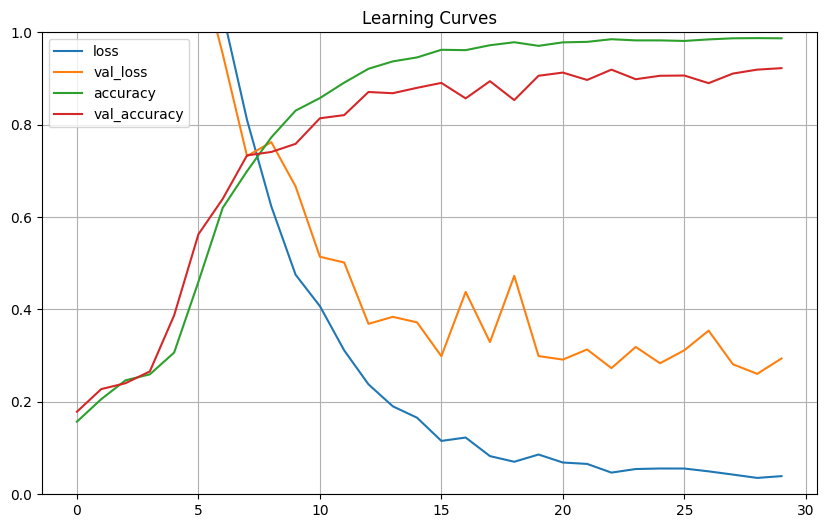

In [ ]:
#Curvas de aprendizaje
df_historial = pd.DataFrame(history_vgg_grid.history)
df_historial[['loss','val_loss','accuracy', 'val_accuracy']].plot(figsize=(10, 6),
                                                                  grid=True,
                                                                  title="Learning Curves",
                                                                  ylim=(0,1));

MEJOR MODELO

In [ ]:
# model_vgg_grid.fit(X_train_vgg, y_train_aug, epochs=30, batch_size=32, validation_data=(X_test_vgg, y_test))

In [ ]:
model_vgg_2.fit(X_train_vgg, y_train_aug, epochs=30, batch_size=32, validation_data=(X_test_vgg, y_test))

Epoch 1/30
294/294 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.3796 - loss: 1.6041 - val_accuracy: 0.3673 - val_loss: 1.6735
Epoch 2/30
294/294 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.3949 - loss: 1.5811 - val_accuracy: 0.3605 - val_loss: 1.6337
Epoch 3/30
294/294 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.4217 - loss: 1.5289 - val_accuracy: 0.3724 - val_loss: 1.6360
Epoch 4/30
294/294 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.4231 - loss: 1.4998 - val_accuracy: 0.3741 - val_loss: 1.6301
Epoch 5/30
294/294 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.4360 - loss: 1.4763 - val_accuracy: 0.4065 - val_loss: 1.6126
Epoch 6/30
294/294 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.4437 - loss: 1.4261 - val_accuracy: 0.4150 - val_loss: 1.5853
Epoch 7/30
294/294 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.4769 - loss: 1.3812 - val_accuracy: 0.4337 - val_loss: 1.5216
Epoch 8/30
294/294 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.4938 - loss: 1.3381 - val_a

In [ ]:
# Evaluar el modelo en el conjunto de entrenamiento
test_loss, test_acc = model_vgg_2.evaluate(X_test_vgg, y_test)

print(f"Pérdida en test: {test_loss:.4f}")
print(f"Exactitud (accuracy) en test: {test_acc:.4f}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6925 - loss: 1.0915
Pérdida en test: 1.0825
Exactitud (accuracy) en test: 0.6667


Aclaración: siempre cuando encuentre el mejor modelo, lo entrene y evalúe, debo entrenarlo con datos aumentados X_train_aug, y_train_aug; y evaluarlo o testearlo con datos no aumentados (o desconodiso por el modelo) X_test, y_test.



---



MODELO PARA PRODUCCIÓN

Le paso todo el set de datos para dejarlo listo en producción.

Aclaración: cuando pongo el modelo en producción, debo usar todos los datos aumentados. Por ello, a X_test e y_test debemos apliacrle las mismas transformaciones para que luego tengamos toda la X e y con datos aumentados (como entrenamos los modelos anteriormente). En otras palabras, el modelo que va a producción, debe usar todos los datos disponibles, y que esos datos también incluyan las transformaciones de data augmentation que se ha aplicado a el conjunto de entrenamiento.


In [ ]:
# Aplicar Data Augmentation a TODO el conjunto de datos test, para despues concatenar y tener todos los datos aumentados de la misma forma
X_test_aug, y_test_aug = augment_dataset_super_simple(X_test_vgg, y_test)

In [ ]:
# Concatenar X_train_aug y X_test_aug para formar X_aug e y_aug
X_aug_vgg = np.concatenate((X_train_vgg, X_test_aug), axis=0)

# Concatenar y_train_aug y y_test_aug para formar y_aug
y_aug = np.concatenate((y_train_aug, y_test_aug), axis=0)

print(f"Shape de X_train_aug: {X_train_aug.shape}")
print(f"Shape de X_test_aug: {X_test_aug.shape}")
print(f"Shape final de X_aug: {X_aug_vgg.shape}")
print("-" * 30)
print(f"Shape de y_train_aug: {y_train_aug.shape}")
print(f"Shape de y_test_aug: {y_test_aug.shape}")
print(f"Shape final de y_aug: {y_aug.shape}")

Shape de X_train_aug: (9400, 48, 48, 3)
Shape de X_test_aug: (2352, 48, 48, 3)
Shape final de X_aug: (11752, 48, 48, 3)
------------------------------
Shape de y_train_aug: (9400,)
Shape de y_test_aug: (2352,)
Shape final de y_aug: (11752,)


In [ ]:
#model_vgg_grid.fit(X_aug_vgg, y_aug, epochs=30, batch_size=32)

In [ ]:
model_vgg_2.fit(X_aug_vgg, y_aug, epochs=30, batch_size=32)

Epoch 1/30
368/368 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.7310 - loss: 0.7629
Epoch 2/30
368/368 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.7436 - loss: 0.7093
Epoch 3/30
368/368 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.7545 - loss: 0.6831
Epoch 4/30
368/368 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.7736 - loss: 0.6332
Epoch 5/30
368/368 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.7872 - loss: 0.6197
Epoch 6/30
368/368 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.7872 - loss: 0.5972
Epoch 7/30
368/368 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.8017 - loss: 0.5620
Epoch 8/30
368/368 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.8019 - loss: 0.5658
Epoch 9/30
368/368 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.8142 - loss: 0.5404
Epoch 10/30
368/368 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.8280 - loss: 0.5023
Epoch 11/30
368/368 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.8303 - loss: 0.4925
Epoch 12/30
368/368 ━━━━━━━━━━━━━━━━

In [ ]:
 #model.fit(X, y, epochs=30, batch_size=32)   # producción sin todo los datos (originales + aumentados) para ver el cambio



---



Guardado del modelo

In [ ]:
# Guardar en formato  Keras
model_vgg_2.save("vgg-16_preentrenado.keras")
print("Modelo guardado como 'vgg-16_preentrenado.keras'.")

Modelo guardado como 'mejor_modelo-mnist.keras'.


Para descargar el modelo guardado

In [ ]:
from google.colab import files

# Descargar el archivo guardado
#files.download("mini_xception_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Mostrar la imagen
#plt.imshow(img[0])  # img[0] porque tiene forma (48, 48, 3)
#plt.axis("off")  # Ocultar ejes
#plt.title("Imagen de prueba")
#plt.show()

Preprocesar imagen antes de probarla

In [ ]:
# Cargar imagen en BGR (OpenCV) o en RGB y convertir a BGR
img = cv2.imread("/content/drive/MyDrive/Colab Notebooks/Procesamiento de imagen/images.jpg")            # devuelve BGR

#  Redimensionar a 48×48
img = cv2.resize(img, (48, 48), interpolation=cv2.INTER_AREA)

# Convertir a float32 y expandir batch
img = img.astype("float32")
img = np.expand_dims(img, axis=0)           # el modelo espera una entrada con forma (N, 48, 48, 3), donde N es el tamaño del batch (cantidad de imágenes) Por eso el 1.

# Aplicar preprocesado de VGG-16
img = preprocess_input(img)                 # internamente esto resta las medias de ImageNet y deja todo listo.


# Predecir
pred = model_vgg_2.predict(img)
clase = np.argmax(pred, axis=1)[0]

print(f"Emoción predicha: {clase}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Emoción predicha: 3


Si se quiere traducir la predicción a nombre de emoción usamos:

In [ ]:
emotion_dict = {0: "Enojo", 1: "Asco", 2: "Miedo", 3: "Feliz",
                4: "Neutral", 5: "Triste", 6: "Sorpresa"}

print(f"Emoción predicha: {emotion_dict[clase]}")


Emoción predicha: Feliz


Imagen de prueba


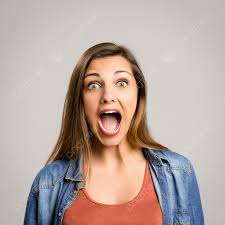



---



Preprocesar imagen antes de probarla

In [ ]:
# Cargar imagen en BGR (OpenCV) o en RGB y convertir a BGR
img2 = cv2.imread("/content/drive/MyDrive/Colab Notebooks/Procesamiento de imagen/imagen_prueba_2.png")            # devuelve BGR

#  Redimensionar a 48×48
img2 = cv2.resize(img2, (48, 48), interpolation=cv2.INTER_AREA)

# Convertir a float32 y expandir batch
img2 = img2.astype("float32")
img2 = np.expand_dims(img2, axis=0)           # el modelo espera una entrada con forma (N, 48, 48, 3), donde N es el tamaño del batch (cantidad de imágenes) Por eso el 1.

# Aplicar preprocesado de VGG-16
img2 = preprocess_input(img2)                 # internamente esto resta las medias de ImageNet y deja todo listo.


# Predecir
pred = model_vgg_2.predict(img2)
clase = np.argmax(pred, axis=1)[0]

print(f"Emoción predicha: {clase}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Emoción predicha: 1


In [ ]:
emotion_dict = {0: "Enojo", 1: "Asco", 2: "Miedo", 3: "Feliz",  4: "Neutral", 5: "Triste", 6: "Sorpresa"}
print(f"Emoción predicha: {emotion_dict[clase]}")

Emoción predicha: Asco


Imagen prueba 2

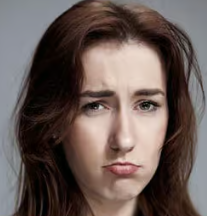



---

